АВТ-213 Гомзякова Софья

## Кейс 1

Задание:

Вариант 2: SGD с затухающей скоростью обучения (learning rate decay)
Модифицируйте базовый SGD, чтобы скорость обучения уменьшалась по формуле: 

lr=lr0/(1+decayrate*epoch)

Используйте lr0=0.1, decay_rate=0.01.

Синтетические данные: y=-1.5x+2+/eps

Начальные веса: w=5, b=5.

Требуется:

1. Сгенерировать данные согласно описанию

2. Реализовать указанную модификацию SGD

3. Обучить модель, вывести финальные параметры

4. Построить график сходимости

import numpy as np
import matplotlib.pyplot as plt

///Ваш код здесь
.//...

print(f"Финальные параметры: w = {w:.4f}, b = {b:.4f}")
print(f"Финальный loss: {loss:.6f}")

Импорты

In [41]:
import numpy as np
import matplotlib.pyplot as plt

Параметры модели

In [42]:
lr0 = 0.1
decay_rate = 0.01
w = 5.0
b = 5.0
n_samples = 20
n_epochs = 20
w_true = -1.5
b_true = 2

Функция для генерации синтетических данных

In [43]:
def y(x, eps):
    return -1.5 * x + 2 + eps

Стохастический градиентный спуск с новым правилом для скорости обучения

In [44]:
def sgd(w0, b0, X, y_true, y_pred, epoch, lr0=0.1, decayrate=0.01):
    dw = -2 * np.mean(X * (y_true - y_pred))
    db = -2 * np.mean(y_true - y_pred)
    lr = lr0 / (1 + decayrate * epoch)
    return w0 - dw * lr, b0 - db * lr, lr

In [45]:
def sgd_old(w0, b0, X, y_true, y_pred, lr=0.1):
    dw = -2 * np.mean(X * (y_true - y_pred))
    db = -2 * np.mean(y_true - y_pred)
    return w0 - dw * lr, b0 - db * lr

Функция потерь (MSE)

In [46]:
def get_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

Генерация данных

In [47]:
X = np.random.randn(n_samples)      * 2
eps = np.random.randn(n_samples)    * 0.5
y_true = y(X, eps)

Обучение

In [48]:
loss_history = []
loss_history_old = []
w_history = []
w_history_old = []
b_history = []
b_history_old = []
lr_history = []
lr_old = [lr0 for i in range(n_epochs)]
w_old = w
b_old = b

for epoch in range(n_epochs):
    indices = [i for i in range(n_samples)]
    np.random.shuffle(indices)
    X_shuffled = X[indices] 
    y_shuffled = y_true[indices]

    y_pred = w * X + b

    w, b, lr = sgd(w, b, X, y_true, y_pred, epoch, lr0, decay_rate)
    
    y_pred_full = w * X + b
    loss = get_loss(y_true, y_pred_full)
    
    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)
    lr_history.append(lr)
    
    print(f"Эпоха {epoch + 1}: lr = {lr}, Loss = {loss}")

    y_pred_old = w_old * X + b_old

    w_old, b_old = sgd_old(w_old, b_old, X, y_true, y_pred_old, lr=lr0)
    y_pred_full_old = w_old * X + b_old
    loss_old = get_loss(y_true, y_pred_full)

    loss_history_old.append(loss_old)
    w_history_old.append(w_old)
    b_history_old.append(b_old)

Эпоха 1: lr = 0.1, Loss = 13.160223857308793
Эпоха 2: lr = 0.09900990099009901, Loss = 3.0884198486200733
Эпоха 3: lr = 0.09803921568627451, Loss = 1.7975984106492686
Эпоха 4: lr = 0.0970873786407767, Loss = 1.2485745497963099
Эпоха 5: lr = 0.09615384615384616, Loss = 0.9065435519807998
Эпоха 6: lr = 0.09523809523809523, Loss = 0.6827609804264506
Эпоха 7: lr = 0.09433962264150944, Loss = 0.5350555863586722
Эпоха 8: lr = 0.09345794392523364, Loss = 0.43709940909871764
Эпоха 9: lr = 0.09259259259259259, Loss = 0.3718579529970286
Эпоха 10: lr = 0.09174311926605505, Loss = 0.3282248180886911
Эпоха 11: lr = 0.09090909090909091, Loss = 0.2989245383101442
Эпоха 12: lr = 0.09009009009009009, Loss = 0.27917057919090743
Эпоха 13: lr = 0.08928571428571429, Loss = 0.26580064488827976
Эпоха 14: lr = 0.08849557522123895, Loss = 0.25671692197834683
Эпоха 15: lr = 0.08771929824561403, Loss = 0.2505221448742637
Эпоха 16: lr = 0.08695652173913045, Loss = 0.24628197409927927
Эпоха 17: lr = 0.086206896551

In [49]:
print(f"Финальные параметры: w = {w:.4f}, b = {b:.4f}")
print(f"Финальный loss: {loss:.6f}")

Финальные параметры: w = -1.5121, b = 1.9394
Финальный loss: 0.239008


Графики

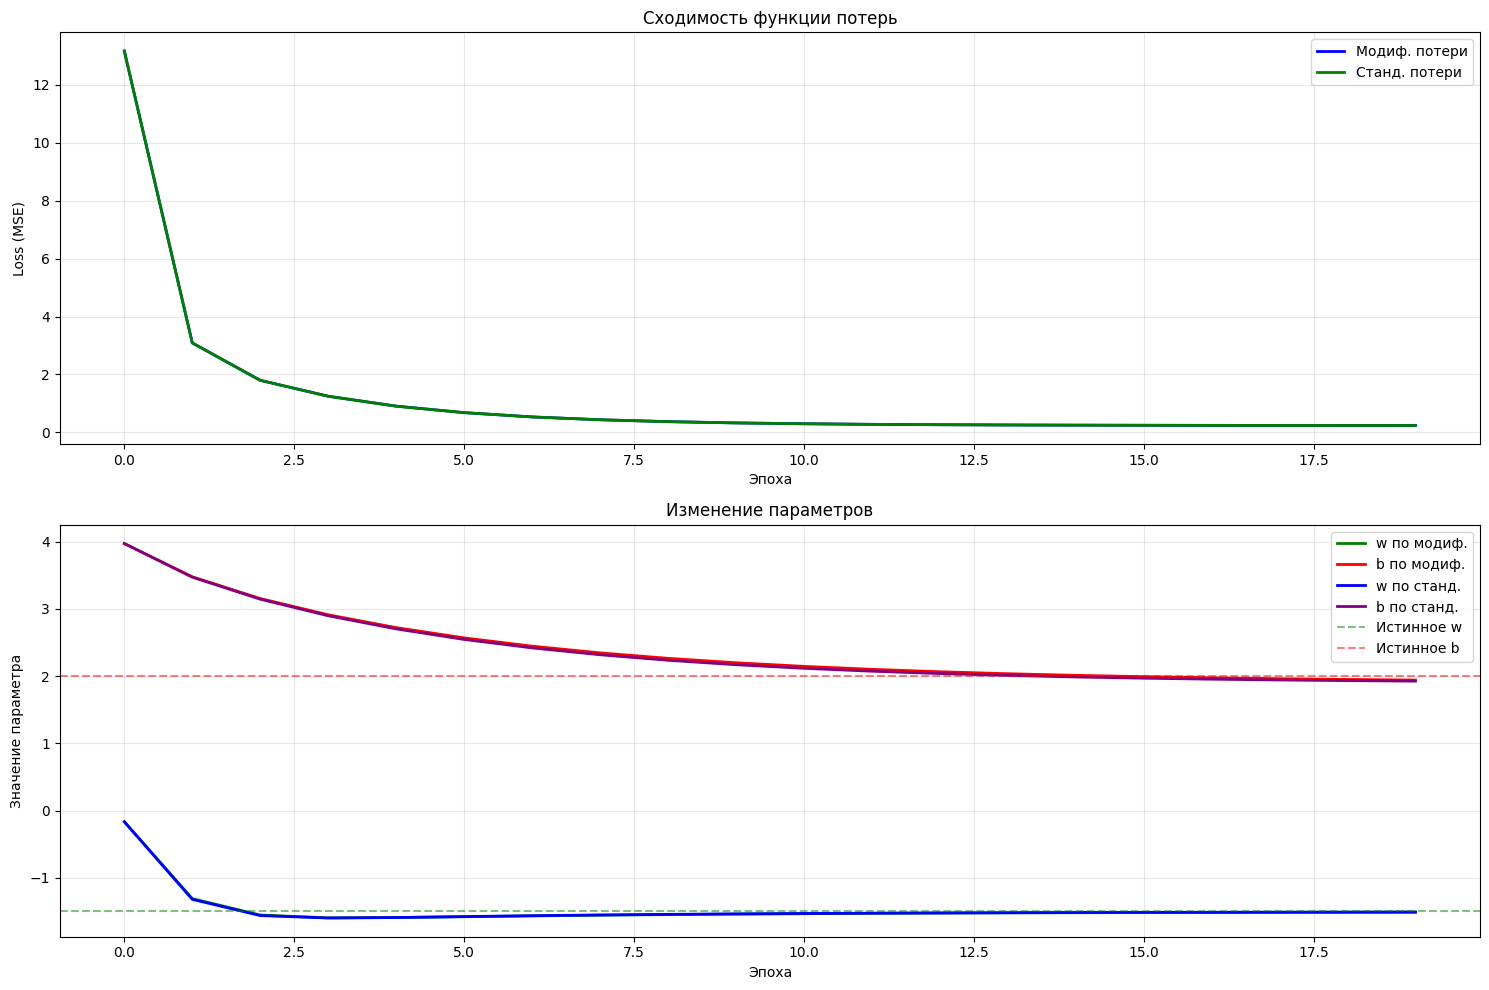

In [50]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(loss_history, 'b-', linewidth=2, label='Модиф. потери')
plt.plot(loss_history_old, 'g-', linewidth=2, label='Станд. потери')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Сходимость функции потерь')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(w_history, 'g-', linewidth=2, label='w по модиф.')
plt.plot(b_history, 'r-', linewidth=2, label='b по модиф.')
plt.plot(w_history_old, 'b-', linewidth=2, label='w по станд.')
plt.plot(b_history_old, color='purple', linewidth=2, label='b по станд.')
plt.axhline(y=w_true, color='g', linestyle='--', alpha=0.5, label='Истинное w')
plt.axhline(y=b_true, color='r', linestyle='--', alpha=0.5, label='Истинное b')
plt.xlabel('Эпоха')
plt.ylabel('Значение параметра')
plt.title('Изменение параметров')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

## Вывод:

Была решена задача модификации скорости обучения в стохастическом градиентном спуске. 